In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx

import torch
import torch.nn.functional as F
from torch_geometric.nn import GCNConv
from torch_geometric_temporal.nn.recurrent import A3TGCN2
from torch_geometric_temporal.signal import temporal_signal_split

# GPU 支持
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Using device:", DEVICE)
shuffle=True
batch_size = 32

Using device: cpu


<h1>
<center>A3T-GCN：用于交通预测的注意力时空图卷积网络</center>
</h1>


## 数据集
- 基于洛杉矶都会区交通的交通预测数据集
- 207 个环路检测器
- 2012 年 3 月 -2012 年 6 月
- 出自论文：Diffusion Convolutional Recurrent Neural Network


In [3]:
from torch_geometric_temporal.dataset import METRLADatasetLoader
loader = METRLADatasetLoader()
dataset = loader.get_dataset(num_timesteps_in=12, num_timesteps_out=12)
print("数据集 type:  ", dataset)
print("Number of samples / sequences: ", dataset.snapshot_count)
print(next(iter(dataset))) # Show first sample

数据集 type:   <torch_geometric_temporal.signal.static_graph_temporal_signal.StaticGraphTemporalSignal object at 0x0000022ED9E9C6A0>
Number of samples / sequences:  34249
Data(x=[207, 2, 12], edge_index=[2, 1722], edge_attr=[1722], y=[207, 12])


#### 数据样本
- 207 个节点
- 每个节点 2 个特征（速度、时间）
- 每个时间桶 12 个时间步（12 x 5 分钟 = 60 分钟） 
- 12 个未来时间步的标签（标准化速度）--> 节点回归
- Edge_attr 基于传感器之间的距离 + 阈值构建
- Further details: https://pytorch-geometric-temporal.readthedocs.io/en/latest/_modules/torch_geometric_temporal/dataset/metr_la.html#METRLA数据集Loader
- 原始数据：https://graphmining.ai/temporal_datasets/METR-LA.zip

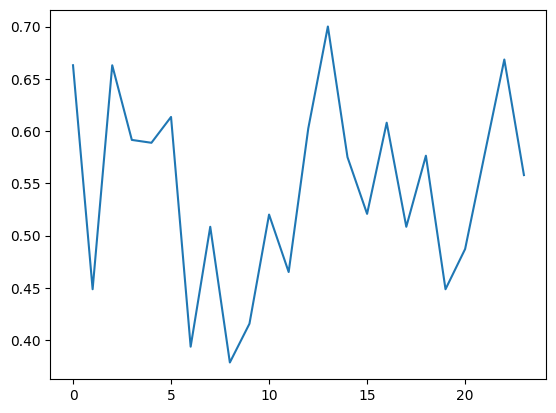

In [4]:
# Visualize traffic over time
sensor_number = 1
hours = 24
sensor_labels = [bucket.y[sensor_number][0].item() for bucket in list(dataset)[:hours]]
plt.plot(sensor_labels)

# 训练集/测试集划分

In [5]:
train_dataset, test_dataset = temporal_signal_split(dataset, train_ratio=0.8)

print("Number of train buckets: ", train_dataset.snapshot_count)
print("Number of test buckets: ", test_dataset.snapshot_count)

Number of train buckets:  27399
Number of test buckets:  6850


# 创建 DataLoaders


In [6]:
train_input  = np.array(train_dataset.features)   # (27399, 207, 2, 12)
train_target = np.array(train_dataset.targets)    # (27399, 207, 12)
train_x_tensor      = torch.from_numpy(train_input).float()   # (B, N, F, T)
train_target_tensor = torch.from_numpy(train_target).float()  # (B, N, T)
train_dataset_new = torch.utils.data.TensorDataset(train_x_tensor, train_target_tensor)
train_loader = torch.utils.data.DataLoader(train_dataset_new, batch_size=batch_size, shuffle=shuffle, drop_last=True)

In [7]:
test_input  = np.array(test_dataset.features)   # (, 207, 2, 12)
test_target = np.array(test_dataset.targets)    # (, 207, 12)
test_x_tensor      = torch.from_numpy(test_input).float()   # (B, N, F, T)
test_target_tensor = torch.from_numpy(test_target).float()  # (B, N, T)
test_dataset_new = torch.utils.data.TensorDataset(test_x_tensor, test_target_tensor)
test_loader = torch.utils.data.DataLoader(test_dataset_new, batch_size=batch_size, shuffle=shuffle, drop_last=True)

## 模型

选择哪个模型取决于你处理的时序任务。

- A3TGCN 是使用注意力机制扩展的 TGCN
- 空间聚合使用 GCN，时间聚合使用 GRU
- 我们可以传入 periods 来获取多个时间步的嵌入
- 这个嵌入可以用于预测未来多个时间步 = 输出维度
- 我们也可以在循环中完成，将其再次输入模型（这将是自回归的）
- 这里只有一个 block。其他层也允许堆叠？？？

<html>
<img src="https://i.ibb.co/WxrJQbc/a3tgcn.png", height="300"></img>

# TGCN 模型

构建了一个结合 GCN 和 GRU 的时间 GCN（T-GCN）模型。

将 n 个历史时间序列交通数据输入 T-GCN 模型，以获得 n 个覆盖时空特征的隐藏状态（h）：{h(t−n), · · · , h(t−1), h(t)}

ut = σ(Wu ∗ (GC(A, Xt), ht−1)) 
rt = σ(Wr ∗ (GC(A, Xt), ht−1)) 
ct = tanh(Wc ∗ (GC(A, Xt), (rt ∗ ht−1)))
ht = ut ∗ ht−1 + (1 − ut) ∗ ct)

然后，将隐藏状态输入注意力模型，以确定覆盖全局交通变化信息的上下文向量。特别是，通过多层感知机使用 Softmax 计算每个 h 的权重：{at−n, · · · , at−1, at}。通过加权和计算覆盖全局交通变化信息的上下文向量。


# A3TGCN 模型

A3TGCN 是通过添加注意力机制对 TGCN 模型的扩展。

引入注意力机制是为了重新加权历史交通状态的影响，从而捕捉交通状态的全局变化趋势

In [8]:
class TemporalGNN(torch.nn.Module):
    def __init__(self, node_features, periods, batch_size):
        super(TemporalGNN, self).__init__()
        # Attention Temporal Graph Convolutional Cell
        self.tgnn = A3TGCN2(in_channels=node_features,  out_channels=32, periods=periods,batch_size=batch_size) # node_features=2, periods=12
        # Equals single-shot prediction
        self.linear = torch.nn.Linear(32, periods)

    def forward(self, x, edge_index):
        """
        x = Node features for T time steps
        edge_index = Graph edge indices
        """
        h = self.tgnn(x, edge_index) # x [b, 207, 2, 12]  returns h [b, 207, 12]
        h = F.relu(h) 
        h = self.linear(h)
        return h

TemporalGNN(node_features=2, periods=12, batch_size=2)

TemporalGNN(
  (tgnn): A3TGCN2(
    (_base_tgcn): TGCN2(
      (conv_z): GCNConv(2, 32)
      (linear_z): Linear(in_features=64, out_features=32, bias=True)
      (conv_r): GCNConv(2, 32)
      (linear_r): Linear(in_features=64, out_features=32, bias=True)
      (conv_h): GCNConv(2, 32)
      (linear_h): Linear(in_features=64, out_features=32, bias=True)
    )
  )
  (linear): Linear(in_features=32, out_features=12, bias=True)
)

## 训练

In [9]:

# Create model and optimizers
model = TemporalGNN(node_features=2, periods=12, batch_size=batch_size).to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
loss_fn = torch.nn.MSELoss()


print('Net\'s state_dict:')
total_param = 0
for param_tensor in model.state_dict():
    print(param_tensor, '\t', model.state_dict()[param_tensor].size())
    total_param += np.prod(model.state_dict()[param_tensor].size())
print('Net\'s total params:', total_param)
#--------------------------------------------------
print('Optimizer\'s state_dict:')
for var_name in optimizer.state_dict():
    print(var_name, '\t', optimizer.state_dict()[var_name])

Net's state_dict:
tgnn._attention 	 torch.Size([12])
tgnn._base_tgcn.conv_z.bias 	 torch.Size([32])
tgnn._base_tgcn.conv_z.lin.weight 	 torch.Size([32, 2])
tgnn._base_tgcn.linear_z.weight 	 torch.Size([32, 64])
tgnn._base_tgcn.linear_z.bias 	 torch.Size([32])
tgnn._base_tgcn.conv_r.bias 	 torch.Size([32])
tgnn._base_tgcn.conv_r.lin.weight 	 torch.Size([32, 2])
tgnn._base_tgcn.linear_r.weight 	 torch.Size([32, 64])
tgnn._base_tgcn.linear_r.bias 	 torch.Size([32])
tgnn._base_tgcn.conv_h.bias 	 torch.Size([32])
tgnn._base_tgcn.conv_h.lin.weight 	 torch.Size([32, 2])
tgnn._base_tgcn.linear_h.weight 	 torch.Size([32, 64])
tgnn._base_tgcn.linear_h.bias 	 torch.Size([32])
linear.weight 	 torch.Size([12, 32])
linear.bias 	 torch.Size([12])
Net's total params: 6936
Optimizer's state_dict:
state 	 {}
param_groups 	 [{'lr': 0.001, 'betas': (0.9, 0.999), 'eps': 1e-08, 'weight_decay': 0, 'amsgrad': False, 'maximize': False, 'foreach': None, 'capturable': False, 'differentiable': False, 'fused': Non

# 加载一次图
# 因为它是静态图

In [10]:
for snapshot in train_dataset:
    static_edge_index = snapshot.edge_index.to(DEVICE)
    break;

In [11]:
model.train()

for epoch in range(1):
    step = 0
    loss_list = []
    for encoder_inputs, labels in train_loader:
        y_hat = model(encoder_inputs, static_edge_index)         # Get model predictions
        loss = loss_fn(y_hat, labels) # Mean squared error #loss = torch.mean((y_hat-labels)**2)  sqrt to change it to rmse
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()
        step= step+ 1
        loss_list.append(loss.item())
        if step % 100 == 0 :
            print(sum(loss_list)/len(loss_list))
    print("Epoch {} train RMSE: {:.4f}".format(epoch, sum(loss_list)/len(loss_list)))

0.7830432730913163
0.6486302073299884
0.5992874793211619
0.5763644530624151
0.5569617158770561
0.5454222089548906
0.5335201469489507
0.5251482436060906
Epoch 0 train RMSE: 0.5203


## 评估

- 让我们获取特定范围的一些样本预测（例如 288/12 = 24 小时）
- 模型每次获取一小时的数据并需要预测下一小时

In [12]:
model.eval()
step = 0
# Store for analysis
total_loss = []
for encoder_inputs, labels in test_loader:
    # Get model predictions
    y_hat = model(encoder_inputs, static_edge_index)
    # Mean squared error
    loss = loss_fn(y_hat, labels)
    total_loss.append(loss.item())
    # Store for analysis below
    #test_labels.append(labels)
    #predictions.append(y_hat)
    

print("Test MSE: {:.4f}".format(sum(total_loss)/len(total_loss)))

Test MSE: 0.5979


### 可视化

- 时间点越远，预测结果越差
- 预测形状：[num_data_points, num_sensors, num_timesteps]

In [13]:
sensor = 123
timestep = 11 
preds = np.asarray([pred[sensor][timestep].detach().cpu().numpy() for pred in y_hat])
labs  = np.asarray([label[sensor][timestep].cpu().numpy() for label in labels])
print("Data points:,", preds.shape)

Data points:, (32,)


<Axes: >

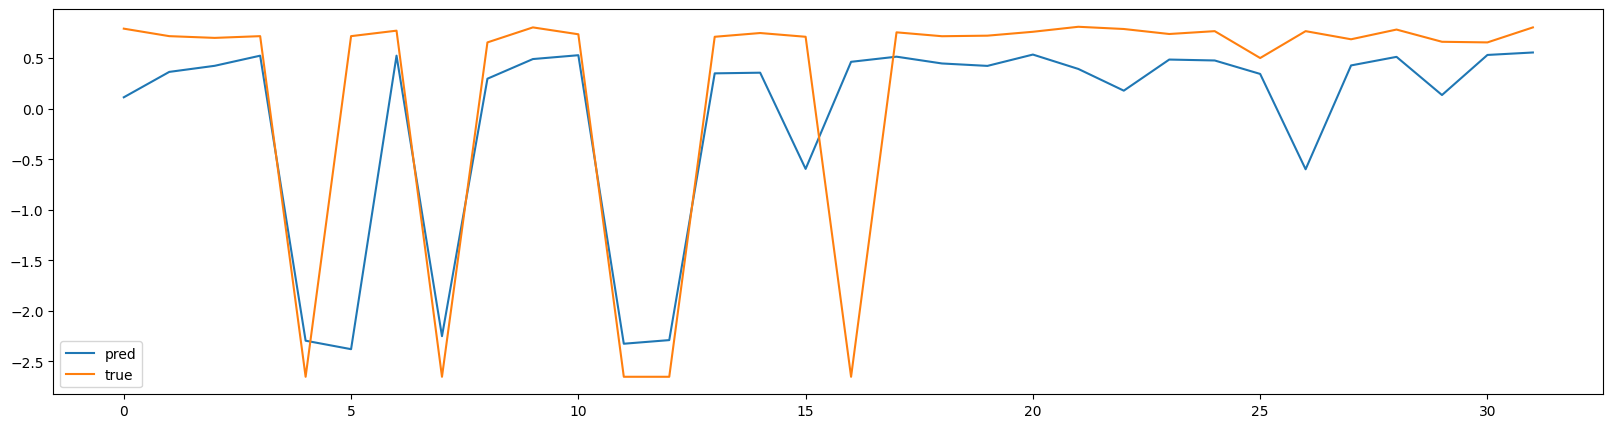

In [14]:
plt.figure(figsize=(20,5))
sns.lineplot(data=preds, label="pred")
sns.lineplot(data=labs, label="true")

In [15]:
sensor = 123
timestep = 2
preds = np.asarray([pred[sensor][timestep].detach().cpu().numpy() for pred in y_hat])
labs  = np.asarray([label[sensor][timestep].cpu().numpy() for label in labels])
print("Data points:,", preds.shape)

Data points:, (32,)


<Axes: >

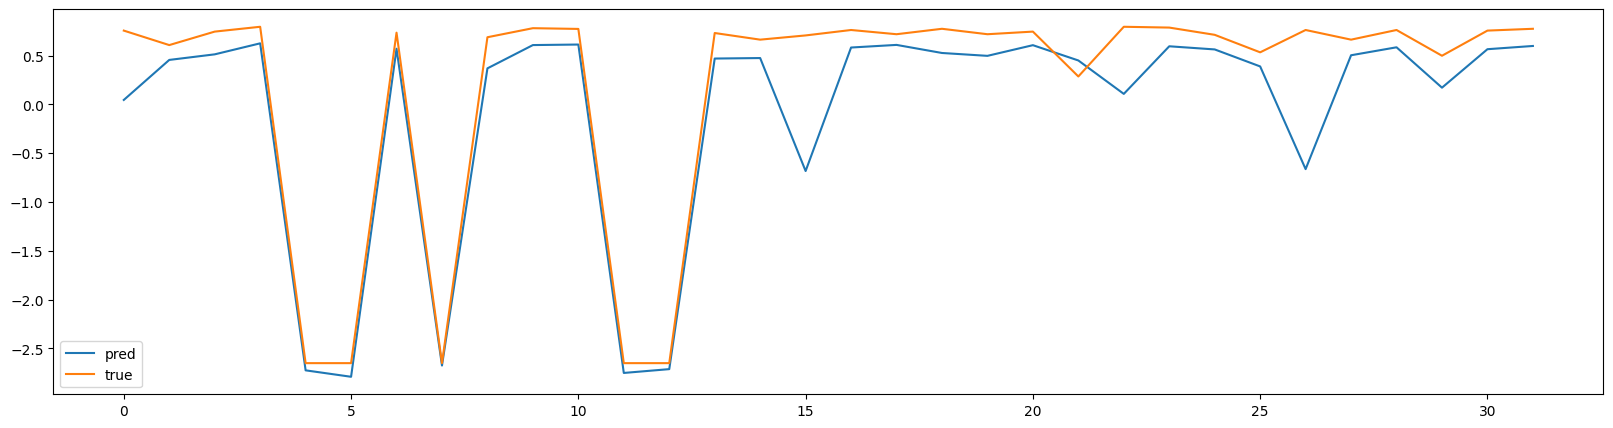

In [16]:
plt.figure(figsize=(20,5))
sns.lineplot(data=preds, label="pred")
sns.lineplot(data=labs, label="true")